# Group 01 — MaleBin — Task 3 Explainability
**Track 2: GCN (Image → Graph)**

## Objective
This notebook analyzes model decisions using three complementary explanation methods:
1. **Grad-CAM** for the ResNet18 baseline
2. **Patch-level local surrogate explanations** for the final GCN
3. **Graph node importance** using patch-node occlusion

The analysis includes one correctly classified sample and one misclassified sample to compare how the models respond to different malware-image regions.


In [3]:

# 1. Imports
import os, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:

# 2. Locate Task 3 outputs automatically inside /kaggle/input
def find_one(filename):
    matches = list(Path("/kaggle/input").rglob(filename))
    if not matches:
        # also allow same-session execution
        matches = list(Path("/kaggle/working").rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"{filename} not found. Add the saved output of the improvement/ablation notebook as a Kaggle Input."
        )
    print(filename, "->", matches[0])
    return matches[0]

manifest_path = find_one("split_manifest_task3.csv")
label_map_path = find_one("label_map.csv")
gcn_ckpt = find_one("Group01_MaleBin_best_gcn.pt")
resnet_ckpt = find_one("Group01_MaleBin_resnet18_fixed.pt")
config_path = find_one("final_model_config.json")

split_manifest = pd.read_csv(manifest_path)
label_map = pd.read_csv(label_map_path).sort_values("label_id")
classes = label_map.label.tolist()
N_CLASSES = len(classes)

with open(config_path) as f:
    config = json.load(f)
print(config)

test_df = split_manifest[split_manifest.split=="test"].reset_index(drop=True)


split_manifest_task3.csv -> /kaggle/input/notebooks/amenaarfa/group01-malebin-task3-improvement-ablation/task3_outputs/split_manifest_task3.csv
label_map.csv -> /kaggle/input/notebooks/amenaarfa/group01-malebin-task3-improvement-ablation/task3_outputs/label_map.csv
Group01_MaleBin_best_gcn.pt -> /kaggle/input/notebooks/amenaarfa/group01-malebin-task3-improvement-ablation/task3_outputs/Group01_MaleBin_best_gcn.pt
Group01_MaleBin_resnet18_fixed.pt -> /kaggle/input/notebooks/amenaarfa/group01-malebin-task3-improvement-ablation/task3_outputs/Group01_MaleBin_resnet18_fixed.pt
final_model_config.json -> /kaggle/input/notebooks/amenaarfa/group01-malebin-task3-improvement-ablation/task3_outputs/final_model_config.json
{'final_name': 'CNN_GCN_4N', 'n_classes': 35, 'grid': 8, 'graph_image_size': 128, 'connectivity': 4, 'weighted': False, 'use_bn': True, 'depth': 3, 'fixed_test_macro_f1': 0.7619658953002879, 'fixed_test_accuracy': 0.7913357400722022, 'resnet_fixed_macro_f1': 0.834444823030133}


In [5]:

# 3. Recreate models exactly
GRID = int(config["grid"])
GRAPH_IMAGE_SIZE = int(config["graph_image_size"])
CNN_IMAGE_SIZE = 224

def make_grid_adjacency(grid=8, connectivity=4, weighted=False):
    n = grid*grid
    A = torch.eye(n, dtype=torch.float32)
    directions = [(1,0),(-1,0),(0,1),(0,-1)]
    if connectivity==8:
        directions += [(1,1),(1,-1),(-1,1),(-1,-1)]
    for r in range(grid):
        for c in range(grid):
            i = r*grid+c
            for dr,dc in directions:
                rr,cc=r+dr,c+dc
                if 0<=rr<grid and 0<=cc<grid:
                    j=rr*grid+cc
                    w=1.0
                    if weighted and abs(dr)+abs(dc)==2:
                        w=1/np.sqrt(2)
                    A[i,j]=max(float(A[i,j]),w)
    d=A.sum(1).clamp_min(1e-8)
    D=torch.diag(d.pow(-0.5))
    return D@A@D

class ConvBackbone(nn.Module):
    def __init__(self, out_grid=8):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(1,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(inplace=True),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1,bias=False),nn.BatchNorm2d(64),nn.ReLU(inplace=True),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1,bias=False),nn.BatchNorm2d(128),nn.ReLU(inplace=True),
        )
        self.pool=nn.AdaptiveAvgPool2d((out_grid,out_grid))
    def forward(self,x): return self.pool(self.features(x))

class GraphConv(nn.Module):
    def __init__(self,a,b):
        super().__init__(); self.linear=nn.Linear(a,b,bias=False)
    def forward(self,x,A): return torch.einsum("ij,bjf->bif",A,self.linear(x))

class NodeBatchNorm(nn.Module):
    def __init__(self,d): super().__init__(); self.bn=nn.BatchNorm1d(d)
    def forward(self,x):
        b,n,f=x.shape
        return self.bn(x.reshape(b*n,f)).reshape(b,n,f)

class CNNFeatureGCN(nn.Module):
    def __init__(self,n_classes,connectivity=8,weighted=True,use_bn=True,hidden=128,dropout=.30,depth=3):
        super().__init__()
        self.backbone=ConvBackbone(GRID)
        self.register_buffer("A",make_grid_adjacency(GRID,connectivity,weighted))
        self.use_bn=use_bn; self.depth=depth; self.dropout=dropout
        self.g1=GraphConv(128,hidden); self.g2=GraphConv(hidden,hidden); self.g3=GraphConv(hidden,hidden)
        self.bn1=NodeBatchNorm(hidden); self.bn2=NodeBatchNorm(hidden); self.bn3=NodeBatchNorm(hidden)
        self.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(hidden*2,n_classes))
    def _act(self,x,bn):
        if self.use_bn: x=bn(x)
        return F.relu(x)
    def image_to_nodes(self,x):
        f=self.backbone(x); return f.flatten(2).transpose(1,2)
    def forward_from_nodes(self,nodes):
        h1=self._act(self.g1(nodes,self.A),self.bn1)
        h1=F.dropout(h1,self.dropout,self.training)
        h2=self._act(self.g2(h1,self.A),self.bn2)
        h2=F.dropout(h2,self.dropout,self.training)
        if self.depth>=3:
            h3=self._act(self.g3(h2,self.A),self.bn3); h=h3+h2
        else: h=h2
        return self.head(torch.cat([h.mean(1),h.amax(1)],1))
    def forward(self,x): return self.forward_from_nodes(self.image_to_nodes(x))

class ResNet18Baseline(nn.Module):
    def __init__(self,n_classes):
        super().__init__()
        m=models.resnet18(weights=None)
        m.conv1=nn.Conv2d(1,64,7,2,3,bias=False)
        m.fc=nn.Linear(m.fc.in_features,n_classes)
        self.model=m
    def forward(self,x): return self.model(x)

gcn = CNNFeatureGCN(
    N_CLASSES, connectivity=int(config["connectivity"]),
    weighted=bool(config["weighted"]), use_bn=bool(config["use_bn"]), depth=int(config["depth"])
).to(device)
gcn.load_state_dict(torch.load(gcn_ckpt, map_location=device))
gcn.eval()

resnet = ResNet18Baseline(N_CLASSES).to(device)
resnet.load_state_dict(torch.load(resnet_ckpt, map_location=device))
resnet.eval()

print("Models loaded.")


Models loaded.


In [6]:

# 4. Data and sample selection: one correct + one wrong final-GCN prediction
gcn_tf = transforms.Compose([
    transforms.Resize((GRAPH_IMAGE_SIZE, GRAPH_IMAGE_SIZE)),
    transforms.ToTensor(), transforms.Normalize([.5],[.5])
])
resnet_tf = transforms.Compose([
    transforms.Resize((CNN_IMAGE_SIZE, CNN_IMAGE_SIZE)),
    transforms.ToTensor(), transforms.Normalize([.5],[.5])
])

def load_tensor(path, tf):
    with Image.open(path) as im:
        return tf(im.convert("L"))

pred_rows=[]
with torch.no_grad():
    for idx,row in test_df.iterrows():
        x=load_tensor(row.path,gcn_tf).unsqueeze(0).to(device)
        p=torch.softmax(gcn(x),1)[0]
        pred=int(p.argmax())
        pred_rows.append((idx,int(row.label_id),pred,float(p.max())))

pred_df=pd.DataFrame(pred_rows,columns=["idx","true","pred","confidence"])
correct = pred_df[pred_df.true==pred_df.pred].sort_values("confidence",ascending=False)
wrong = pred_df[pred_df.true!=pred_df.pred].sort_values("confidence",ascending=False)

assert len(correct)>0, "No correct prediction found."
correct_idx=int(correct.iloc[0].idx)
wrong_idx=int(wrong.iloc[0].idx) if len(wrong) else int(correct.iloc[-1].idx)

selected=[("Correct",correct_idx),("Wrong",wrong_idx)]
display(pd.DataFrame([
    {
        "case":case,"index":idx,
        "true":classes[int(test_df.iloc[idx].label_id)],
        "gcn_pred":classes[int(pred_df.set_index("idx").loc[idx].pred)],
        "confidence":float(pred_df.set_index("idx").loc[idx].confidence)
    } for case,idx in selected
]))


,case,index,true,gcn_pred,confidence
0,Correct,148,Malware_Merge/Lolyda.AA3,Malware_Merge/Lolyda.AA3,0.999757
1,Wrong,552,Malware_Merge/CoinMinerXMRig,Malware_Merge/Lolyda.AA2,0.975877


In [7]:

# 5. Grad-CAM for the ResNet18 baseline
class GradCAM:
    def __init__(self, model, layer):
        self.model=model
        self.activations=None
        self.gradients=None
        self.h1=layer.register_forward_hook(self._forward)
        self.h2=layer.register_full_backward_hook(self._backward)
    def _forward(self,m,i,o): self.activations=o.detach()
    def _backward(self,m,gi,go): self.gradients=go[0].detach()
    def __call__(self,x,class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits=self.model(x)
        if class_idx is None: class_idx=int(logits.argmax(1).item())
        logits[0,class_idx].backward()
        w=self.gradients.mean(dim=(2,3),keepdim=True)
        cam=(w*self.activations).sum(1,keepdim=True)
        cam=F.relu(cam)
        cam=F.interpolate(cam,size=x.shape[-2:],mode="bilinear",align_corners=False)
        cam=cam[0,0]
        cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), class_idx

gradcam=GradCAM(resnet,resnet.model.layer4[-1])


In [8]:

# 6. LIME at patch/superpixel level (self-contained local weighted surrogate)
# Each 8×8 patch is treated as one interpretable superpixel.
def lime_patch_importance(model, x, target_class=None, grid=8, n_samples=500, batch=64):
    model.eval()
    with torch.no_grad():
        p0=torch.softmax(model(x.to(device)),1)[0]
    if target_class is None:
        target_class=int(p0.argmax())

    rng=np.random.default_rng(SEED)
    masks=rng.integers(0,2,size=(n_samples,grid*grid),dtype=np.int64)
    masks[0,:]=1

    _,_,H,W=x.shape
    ph,pw=H//grid,W//grid
    baseline=x.mean().item()
    outputs=[]

    for start in range(0,n_samples,batch):
        chunk=masks[start:start+batch]
        xb=x.repeat(len(chunk),1,1,1).clone()
        for bi,mask in enumerate(chunk):
            for node,on in enumerate(mask):
                if on==0:
                    r,c=divmod(node,grid)
                    xb[bi,:,r*ph:(r+1)*ph,c*pw:(c+1)*pw]=baseline
        with torch.no_grad():
            pr=torch.softmax(model(xb.to(device)),1)[:,target_class].cpu().numpy()
        outputs.append(pr)
    y=np.concatenate(outputs)

    # LIME kernel: perturbations closer to the full sample get larger weight.
    frac_off=1-masks.mean(axis=1)
    kernel_width=0.25
    sample_weight=np.exp(-(frac_off**2)/(kernel_width**2))
    surrogate=Ridge(alpha=1.0)
    surrogate.fit(masks,y,sample_weight=sample_weight)
    importance=surrogate.coef_.reshape(grid,grid)
    return importance,target_class

# 7. GCN node importance via patch-node occlusion
# Importance = drop in target-class probability when that patch/node is removed.
def node_occlusion_importance(model, x, target_class=None, grid=8):
    model.eval()
    with torch.no_grad():
        base_p=torch.softmax(model(x.to(device)),1)[0]
    if target_class is None:
        target_class=int(base_p.argmax())
    base_score=float(base_p[target_class])

    _,_,H,W=x.shape
    ph,pw=H//grid,W//grid
    baseline=x.mean().item()
    pert=[]
    for node in range(grid*grid):
        z=x.clone()
        r,c=divmod(node,grid)
        z[:,:,r*ph:(r+1)*ph,c*pw:(c+1)*pw]=baseline
        pert.append(z)
    xb=torch.cat(pert,0)
    with torch.no_grad():
        scores=torch.softmax(model(xb.to(device)),1)[:,target_class].cpu().numpy()
    imp=(base_score-scores).reshape(grid,grid)
    return imp,target_class


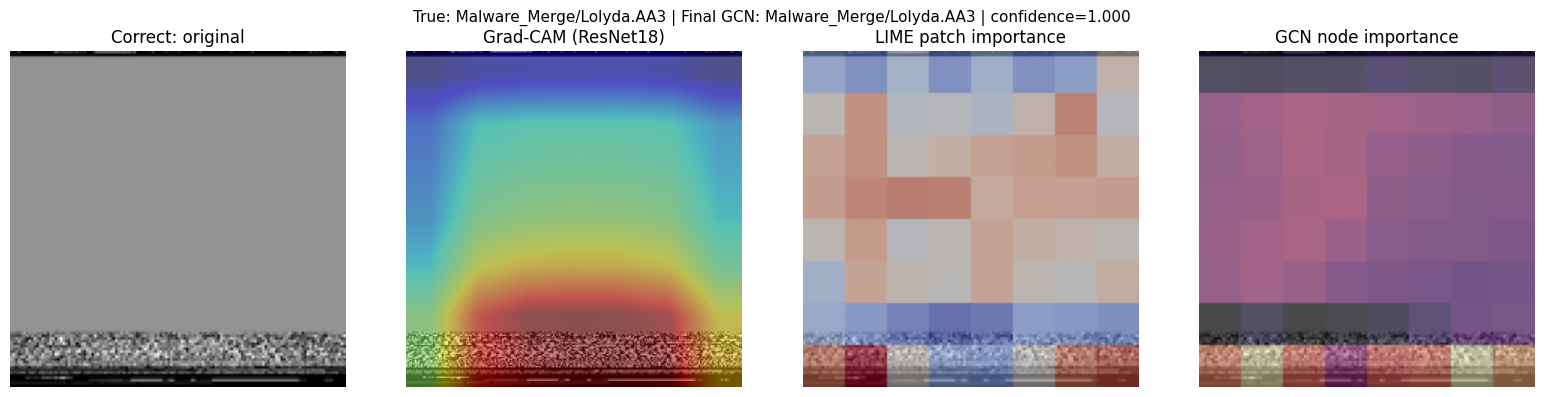

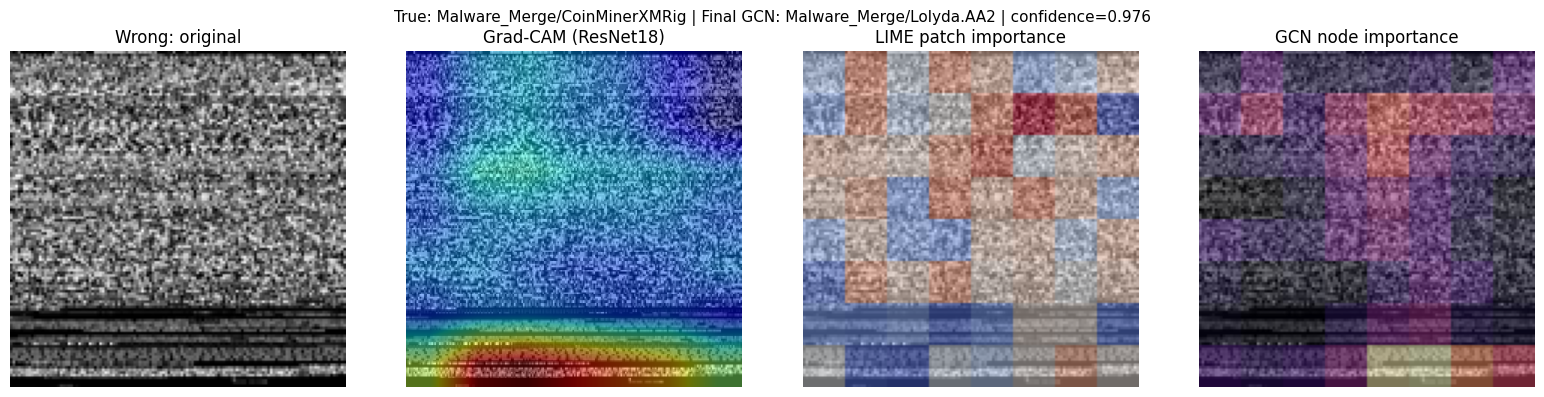

,case,true_class,final_gcn_prediction,gcn_confidence,resnet_gradcam_class,lime_target_class,node_importance_target,figure
0,Correct,Malware_Merge/Lolyda.AA3,Malware_Merge/Lolyda.AA3,0.999757,Malware_Merge/Lolyda.AA3,Malware_Merge/Lolyda.AA3,Malware_Merge/Lolyda.AA3,/kaggle/working/task3_xai_outputs/correct_xai.png
1,Wrong,Malware_Merge/CoinMinerXMRig,Malware_Merge/Lolyda.AA2,0.975877,Malware_Merge/Gozi,Malware_Merge/Lolyda.AA2,Malware_Merge/Lolyda.AA2,/kaggle/working/task3_xai_outputs/wrong_xai.png



Interpretation note:
MaleBin images are byte-derived malware textures, not natural physical regions.
Grad-CAM, local-surrogate, and node-importance heatmaps indicate model-sensitive byte-image areas,
but these regions should not be interpreted as direct semantic malware-code regions.


In [9]:

# 8. Generate XAI figures for one correct and one wrong sample
XAI_OUT=Path("/kaggle/working/task3_xai_outputs")
XAI_OUT.mkdir(parents=True,exist_ok=True)

summary=[]

for case,idx in selected:
    row=test_df.iloc[idx]
    with Image.open(row.path) as im:
        raw=np.array(im.convert("L").resize((GRAPH_IMAGE_SIZE,GRAPH_IMAGE_SIZE)))

    xg=load_tensor(row.path,gcn_tf).unsqueeze(0)
    xr=load_tensor(row.path,resnet_tf).unsqueeze(0).to(device)

    with torch.no_grad():
        gp=torch.softmax(gcn(xg.to(device)),1)[0]
        gpred=int(gp.argmax())

    cam,rpred=gradcam(xr)
    lime_imp,lime_target=lime_patch_importance(gcn,xg,target_class=gpred,grid=GRID,n_samples=400)
    node_imp,node_target=node_occlusion_importance(gcn,xg,target_class=gpred,grid=GRID)

    # Resize heatmaps for overlay
    lime_t=torch.tensor(lime_imp,dtype=torch.float32)[None,None]
    lime_up=F.interpolate(lime_t,size=(GRAPH_IMAGE_SIZE,GRAPH_IMAGE_SIZE),mode="nearest")[0,0].numpy()
    node_t=torch.tensor(node_imp,dtype=torch.float32)[None,None]
    node_up=F.interpolate(node_t,size=(GRAPH_IMAGE_SIZE,GRAPH_IMAGE_SIZE),mode="nearest")[0,0].numpy()

    fig,axes=plt.subplots(1,4,figsize=(16,4))
    axes[0].imshow(raw,cmap="gray"); axes[0].set_title(f"{case}: original")
    axes[1].imshow(np.array(Image.open(row.path).convert("L").resize((CNN_IMAGE_SIZE,CNN_IMAGE_SIZE))),cmap="gray")
    axes[1].imshow(cam,alpha=.45,cmap="jet"); axes[1].set_title("Grad-CAM (ResNet18)")
    axes[2].imshow(raw,cmap="gray"); axes[2].imshow(lime_up,alpha=.5,cmap="coolwarm")
    axes[2].set_title("LIME patch importance")
    axes[3].imshow(raw,cmap="gray"); axes[3].imshow(node_up,alpha=.5,cmap="magma")
    axes[3].set_title("GCN node importance")
    for ax in axes: ax.axis("off")
    fig.suptitle(
        f"True: {classes[int(row.label_id)]} | Final GCN: {classes[gpred]} | confidence={float(gp[gpred]):.3f}",
        fontsize=11
    )
    plt.tight_layout()
    path=XAI_OUT/f"{case.lower()}_xai.png"
    plt.savefig(path,dpi=180,bbox_inches="tight")
    plt.show()

    summary.append({
        "case":case,
        "true_class":classes[int(row.label_id)],
        "final_gcn_prediction":classes[gpred],
        "gcn_confidence":float(gp[gpred]),
        "resnet_gradcam_class":classes[rpred],
        "lime_target_class":classes[lime_target],
        "node_importance_target":classes[node_target],
        "figure":str(path)
    })

summary_df=pd.DataFrame(summary)
summary_df.to_csv(XAI_OUT/"xai_summary.csv",index=False)
display(summary_df)

print("\nInterpretation note:")
print("MaleBin images are byte-derived malware textures, not natural physical regions.")
print("Grad-CAM, local-surrogate, and node-importance heatmaps indicate model-sensitive byte-image areas,")
print("but these regions should not be interpreted as direct semantic malware-code regions.")


## Interpretation Considerations

For correctly classified samples, the explanation maps can be compared to determine whether the different methods emphasize similar image regions. For misclassified samples, dispersed or conflicting importance patterns may indicate that the model relied on features shared with another malware family.

MaleBin images are byte-derived grayscale representations rather than natural images. Therefore, highlighted patches indicate regions that influence model predictions in the image representation, but they should not be interpreted as direct evidence of specific malware functions or source-code semantics.
